# Pre-processing of Synthea for LLOS Prediction

Adapts the MIMIC IV preprocessing pipeline for Synthea data using SNOMED codes directly.
Target: Predict Long Length of Stay (LLOS = LOS ≥ mean + 2σ)

In [1]:
# Paths configuration
synthea_path = "../output_synthea/csv"
notes_path = "../output_synthea/notes"
output_path = "./datasets/synthea_processed"

import os
os.makedirs(output_path, exist_ok=True)

## 1. Physical characteristics extraction and LOS calculation
Filter to inpatient encounters only, calculate LOS, create LLOS binary label

In [2]:
import pandas as pd
import numpy as np

# Load Synthea data
encounters_df = pd.read_csv(f"{synthea_path}/encounters.csv")
patients_df = pd.read_csv(f"{synthea_path}/patients.csv")

print("Encounters shape:", encounters_df.shape)
print("Patients shape:", patients_df.shape)
print("\nEncounter classes:", encounters_df['ENCOUNTERCLASS'].value_counts())

Encounters shape: (6765013, 15)
Patients shape: (114830, 28)

Encounter classes: ENCOUNTERCLASS
ambulatory    3742447
wellness      1398293
outpatient     865559
urgentcare     305395
emergency      256422
inpatient      110841
home            36647
snf             17077
hospice         16219
virtual         16113
Name: count, dtype: int64


In [3]:
# Filter to inpatient encounters only (these have meaningful multi-day LOS)
df_enc = encounters_df[encounters_df['ENCOUNTERCLASS'] == 'inpatient'].copy()
print(f"Inpatient encounters: {len(df_enc)}")

# Rename columns to match MIMIC format
df_enc = df_enc.rename(columns={
    'Id': 'hadm_id',
    'PATIENT': 'subject_id',
    'ENCOUNTERCLASS': 'admission_type',
    'START': 'admittime',
    'STOP': 'dischtime',
    'REASONCODE': 'reason_code',
    'REASONDESCRIPTION': 'reason_description'
})

# Merge with patient demographics
patients_df = patients_df.rename(columns={
    'Id': 'subject_id',
    'GENDER': 'gender',
    'RACE': 'race',
    'ETHNICITY': 'ethnicity',
    'MARITAL': 'marital_status',
    'BIRTHDATE': 'birthdate'
})

df_phy_ad = pd.merge(
    df_enc[['subject_id', 'hadm_id', 'admission_type', 'admittime', 'dischtime', 'reason_code', 'reason_description']],
    patients_df[['subject_id', 'gender', 'race', 'ethnicity', 'marital_status', 'birthdate']],
    on='subject_id',
    how='left'
)

print(f"Merged shape: {df_phy_ad.shape}")

Inpatient encounters: 110841
Merged shape: (110841, 12)


In [92]:
df_phy_ad.head()

,subject_id,hadm_id,admission_type,admittime,dischtime,reason_code,reason_description,gender,race,ethnicity,marital_status,birthdate
0,c86c400e-ff88-a1e3-2e23-caa4d8311f47,c86c400e-ff88-a1e3-d19d-f82069d9783e,inpatient,1976-08-09T12:23:57Z,1976-08-10T12:23:57Z,39898005.0,Sleep disorder (disorder),M,white,hispanic,S,1946-08-01
1,982750f4-569b-5949-196b-60699bdda3fb,982750f4-569b-5949-6251-9aeb2c196041,inpatient,2021-10-17T10:18:01Z,2021-10-18T10:18:01Z,183996000.0,Sterilization requested (situation),F,white,nonhispanic,M,1986-04-12
2,62f60bdb-cc5c-8305-b98b-f2b229a55eca,62f60bdb-cc5c-8305-4a15-c0c0d9bd6add,inpatient,2010-08-03T03:00:00Z,2010-08-04T03:00:00Z,183996000.0,Sterilization requested (situation),F,white,nonhispanic,M,1975-03-23
3,e74367bd-7385-97dc-2c7f-251b4cd9fe29,e74367bd-7385-97dc-909d-528faf7271b3,inpatient,2017-07-24T10:35:06Z,2017-07-30T15:13:14Z,254837009.0,Malignant neoplasm of breast (disorder),F,white,nonhispanic,M,1960-02-23
4,e74367bd-7385-97dc-2c7f-251b4cd9fe29,e74367bd-7385-97dc-ec13-b81adc0b73ae,inpatient,2018-02-20T08:31:22Z,2018-02-27T15:17:53Z,698306007.0,Awaiting transplantation of kidney (situation),F,white,nonhispanic,M,1960-02-23


In [4]:
# Calculate LOS in days
df_phy_ad['admittime'] = pd.to_datetime(df_phy_ad['admittime'], utc=True)
df_phy_ad['dischtime'] = pd.to_datetime(df_phy_ad['dischtime'], utc=True)
df_phy_ad = df_phy_ad.dropna(subset=['admittime', 'dischtime']).copy()

df_phy_ad['LOS'] = (df_phy_ad['dischtime'] - df_phy_ad['admittime']).dt.total_seconds() / (3600 * 24)
df_phy_ad['LOS'] = df_phy_ad['LOS'].round(6)

# Calculate age at admission (handle timezone-aware/naive mismatch)
df_phy_ad['birthdate'] = pd.to_datetime(df_phy_ad['birthdate'], utc=True)
df_phy_ad['anchor_age'] = ((df_phy_ad['admittime'] - df_phy_ad['birthdate']).dt.days / 365.25).astype(int)

# Filter reasonable LOS (0-500 days like MIMIC pipeline)
condition = (df_phy_ad['LOS'] >= 0) & (df_phy_ad['LOS'] <= 500)
df_phy_ad = df_phy_ad[condition]

print(f"After LOS filter: {len(df_phy_ad)} encounters")
print(f"\nLOS statistics:")
print(df_phy_ad['LOS'].describe())

After LOS filter: 110841 encounters

LOS statistics:
count    110841.000000
mean          4.748777
std           4.808993
min           1.000000
25%           1.000000
50%           3.421528
75%           6.494444
max         118.588634
Name: LOS, dtype: float64


In [5]:
# Numeric mapping for categorical variables (Synthea-specific values)
gender_nums = {'F': 1, 'M': 2}
race_nums = {'white': 1, 'black': 2, 'asian': 3, 'native': 4, 'other': 5}
marital_nums = {'S': 1, 'M': 2, 'D': 3, 'W': 4}  # Single, Married, Divorced, Widowed
admission_nums = {'inpatient': 1, 'emergency': 2, 'urgentcare': 3, 'ambulatory': 4, 'wellness': 5, 'outpatient': 6}

# Apply mappings
df_phy_ad['gender'] = df_phy_ad['gender'].map(gender_nums).fillna(0).astype(int)
df_phy_ad['race'] = df_phy_ad['race'].str.lower().map(race_nums).fillna(0).astype(int)
df_phy_ad['marital_status'] = df_phy_ad['marital_status'].map(marital_nums).fillna(0).astype(int)
df_phy_ad['admission_type'] = df_phy_ad['admission_type'].str.lower().map(admission_nums).fillna(0).astype(int)

print("Gender distribution:", df_phy_ad['gender'].value_counts().to_dict())
print("Race distribution:", df_phy_ad['race'].value_counts().to_dict())

Gender distribution: {2: 62857, 1: 47984}
Race distribution: {1: 91834, 2: 8834, 3: 7337, 5: 1166, 0: 1133, 4: 537}


In [6]:
# Calculate LLOS threshold (mean + 2σ) from the full inpatient population
los_mean = df_phy_ad['LOS'].mean()
los_std = df_phy_ad['LOS'].std()
los_threshold = los_mean + 2 * los_std

print(f"LOS mean:                  {los_mean:.2f} days")
print(f"LOS std:                   {los_std:.2f} days")
print(f"LLOS threshold (mean+2σ):  {los_threshold:.2f} days")
print(f"\nEncounters with LOS >= threshold: {(df_phy_ad['LOS'] >= los_threshold).sum()} "
      f"({(df_phy_ad['LOS'] >= los_threshold).mean()*100:.1f}% of all inpatient encounters)")


LOS mean:                  4.75 days
LOS std:                   4.81 days
LLOS threshold (mean+2σ):  14.37 days

Encounters with LOS >= threshold: 4144 (3.7% of all inpatient encounters)


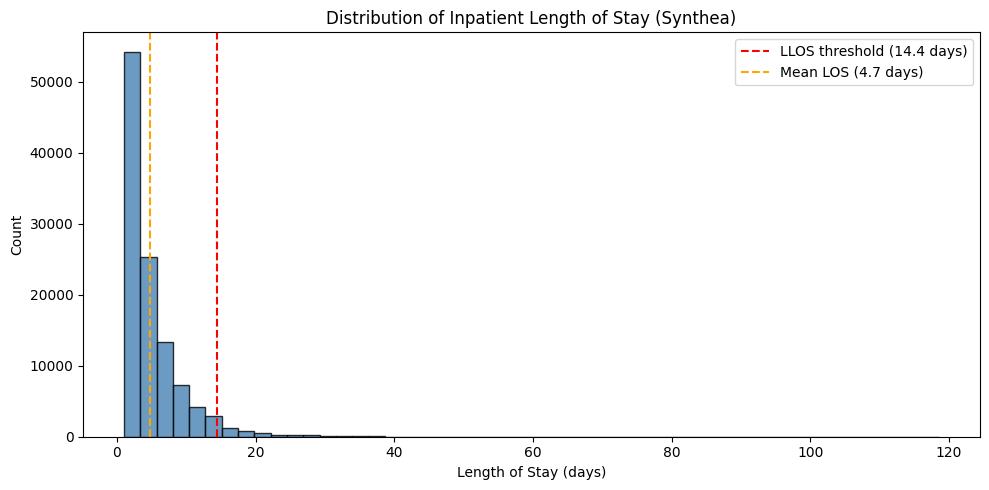

Saved histogram to ./datasets/synthea_processed/los_histogram.png


In [96]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_phy_ad['LOS'], bins=50, edgecolor='black', color='steelblue', alpha=0.8)
ax.axvline(los_threshold, color='red', linestyle='--', linewidth=1.5, label=f'LLOS threshold ({los_threshold:.1f} days)')
ax.axvline(los_mean, color='orange', linestyle='--', linewidth=1.5, label=f'Mean LOS ({los_mean:.1f} days)')
ax.set_xlabel('Length of Stay (days)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Inpatient Length of Stay (Synthea)')
ax.legend()
plt.tight_layout()

hist_path = f"{output_path}/los_histogram.png"
fig.savefig(hist_path, dpi=150)
plt.show()
print(f"Saved histogram to {hist_path}")


In [7]:
# Filter dataset to LLOS patients only (LOS >= threshold)
# All further steps only concern this high-acuity cohort;
# the regression target is their actual LOS value.
n_before = len(df_phy_ad)
df_phy_ad = df_phy_ad[df_phy_ad['LOS'] >= los_threshold].copy()
n_after = len(df_phy_ad)

print(f"Before LLOS filter: {n_before} encounters")
print(f"After  LLOS filter: {n_after} encounters  ({n_after/n_before*100:.1f}% retained)")
print(f"\nLOS statistics for LLOS cohort:")
print(df_phy_ad['LOS'].describe())


Before LLOS filter: 110841 encounters
After  LLOS filter: 4144 encounters  (3.7% retained)

LOS statistics for LLOS cohort:
count    4144.000000
mean       20.902322
std         8.250982
min        14.368750
25%        16.000000
50%        18.148264
75%        22.905266
max       118.588634
Name: LOS, dtype: float64


In [8]:
# Save physical + admission data (LLOS cohort only; LOS is the regression target)
cols_to_save = ['subject_id', 'hadm_id', 'admission_type', 'marital_status', 'race',
                'gender', 'anchor_age', 'admittime', 'dischtime', 'LOS']
df_phy_ad[cols_to_save].to_csv(f"{output_path}/phy_ad.csv", index=False)

print(f"Saved {len(df_phy_ad)} LLOS encounters to phy_ad.csv")
print(f"Unique patients: {df_phy_ad['subject_id'].nunique()}")


Saved 4144 LLOS encounters to phy_ad.csv
Unique patients: 3262


## 2. Diagnosis SNOMED codes one-hot encoding

In [9]:
import pandas as pd

df_phy = pd.read_csv(f"{output_path}/phy_ad.csv")
conditions_df = pd.read_csv(f"{synthea_path}/conditions.csv")

print("Conditions shape:", conditions_df.shape)
print(conditions_df.head())

Conditions shape: (4163865, 7)
        START        STOP                               PATIENT  \
0  2017-08-17  2017-08-17  76b20010-c318-5754-8c85-983aa538522f   
1  2017-09-21  2017-11-23  76b20010-c318-5754-8c85-983aa538522f   
2  2017-11-30  2017-12-16  76b20010-c318-5754-8c85-983aa538522f   
3  2018-01-25  2018-04-26  76b20010-c318-5754-8c85-983aa538522f   
4  2018-07-26  2018-10-25  76b20010-c318-5754-8c85-983aa538522f   

                              ENCOUNTER     SYSTEM       CODE  \
0  76b20010-c318-5754-57e2-651f596ddb8c  SNOMED-CT  314529007   
1  76b20010-c318-5754-d83c-7cf85a83d079  SNOMED-CT  314529007   
2  76b20010-c318-5754-8283-493693157ccd  SNOMED-CT   10509002   
3  76b20010-c318-5754-86a2-535ab39ce5ad  SNOMED-CT  314529007   
4  76b20010-c318-5754-e480-f6e1ced02a7a  SNOMED-CT  314529007   

                         DESCRIPTION  
0  Medication review due (situation)  
1  Medication review due (situation)  
2        Acute bronchitis (disorder)  
3  Medication revie

In [10]:
# Rename columns to match our format
df_cond = conditions_df.rename(columns={
    'PATIENT': 'subject_id',
    'ENCOUNTER': 'hadm_id',
    'CODE': 'snomed_code',
    'DESCRIPTION': 'description'
})

# Keep only conditions from our filtered encounters
keep_keys = df_phy[['subject_id', 'hadm_id']].drop_duplicates()
df_cond = df_cond.merge(keep_keys, on=['subject_id', 'hadm_id'], how='inner')

# Clean SNOMED codes
df_cond['snomed_code'] = df_cond['snomed_code'].astype(str).str.strip()
df_cond = df_cond.drop_duplicates(subset=['subject_id', 'hadm_id', 'snomed_code'])

print(f"Filtered conditions: {len(df_cond)}")
print(f"Unique SNOMED codes: {df_cond['snomed_code'].nunique()}")

Filtered conditions: 655
Unique SNOMED codes: 14


In [11]:
# One-hot encode SNOMED diagnosis codes
dummies = pd.get_dummies(df_cond['snomed_code'], prefix='d', dtype='uint8')

cond_sparse = pd.concat([df_cond[['subject_id', 'hadm_id']].reset_index(drop=True), dummies], axis=1)
df_cond_encoded = cond_sparse.groupby(['subject_id', 'hadm_id'], sort=False).max().reset_index()

print(f"One-hot encoded diagnoses shape: {df_cond_encoded.shape}")

One-hot encoded diagnoses shape: (653, 16)


In [12]:
# Merge with physical characteristics
merged_df = pd.merge(df_phy, df_cond_encoded, on=['subject_id', 'hadm_id'], how='left')

d_cols = [c for c in merged_df.columns if c.startswith('d_')]
if d_cols:
    merged_df[d_cols] = merged_df[d_cols].fillna(0).astype('uint8')

print(f"Final merged shape: {merged_df.shape}")
merged_df.to_csv(f"{output_path}/phyad_dicd.csv", index=False)
print("Saved phyad_dicd.csv")

Final merged shape: (4144, 24)
Saved phyad_dicd.csv


## 3. Procedure SNOMED codes one-hot encoding

In [13]:
import pandas as pd

df_phyad_dicd = pd.read_csv(f"{output_path}/phyad_dicd.csv")
procedures_df = pd.read_csv(f"{synthea_path}/procedures.csv")

print("Loaded diagnosis-merged dataset:", df_phyad_dicd.shape)
print("Procedures shape:", procedures_df.shape)

Loaded diagnosis-merged dataset: (4144, 24)
Procedures shape: (18772642, 10)


In [14]:
# Rename and filter procedures
df_proc = procedures_df.rename(columns={
    'PATIENT': 'subject_id',
    'ENCOUNTER': 'hadm_id',
    'CODE': 'snomed_code',
    'DESCRIPTION': 'description'
})

keep_keys_proc = df_phyad_dicd[['subject_id', 'hadm_id']].drop_duplicates()
df_proc = df_proc.merge(keep_keys_proc, on=['subject_id', 'hadm_id'], how='inner')

df_proc['snomed_code'] = df_proc['snomed_code'].astype(str).str.strip()
df_proc = df_proc.drop_duplicates(subset=['subject_id', 'hadm_id', 'snomed_code'])

print(f"Filtered procedures: {len(df_proc)}")
print(f"Unique procedure codes: {df_proc['snomed_code'].nunique()}")

Filtered procedures: 6035
Unique procedure codes: 38


In [15]:
# One-hot encode procedure codes
p_dummies = pd.get_dummies(df_proc['snomed_code'], prefix='p', dtype='uint8')

proc_block = pd.concat([df_proc[['subject_id', 'hadm_id']].reset_index(drop=True), p_dummies], axis=1)
df_proc_encoded = proc_block.groupby(['subject_id', 'hadm_id'], sort=False).max().reset_index()

print(f"Procedures one-hot encoded shape: {df_proc_encoded.shape}")

Procedures one-hot encoded shape: (2189, 40)


In [16]:
# Merge with existing data
merged_df = df_phyad_dicd.merge(df_proc_encoded, on=['subject_id', 'hadm_id'], how='left')

p_cols = [c for c in merged_df.columns if c.startswith('p_')]
if p_cols:
    merged_df[p_cols] = merged_df[p_cols].fillna(0).astype('uint8')

print(f"Final merged shape: {merged_df.shape}")
merged_df.to_csv(f"{output_path}/phyad_dicd_picd.csv", index=False)
print("Saved phyad_dicd_picd.csv")

Final merged shape: (4144, 62)
Saved phyad_dicd_picd.csv


## 4. Medication frequency processing (RxNorm codes)

In [17]:
import pandas as pd
import re

df_other = pd.read_csv(f"{output_path}/phyad_dicd_picd.csv")
medications_df = pd.read_csv(f"{synthea_path}/medications.csv")

print("Medications shape:", medications_df.shape)
print(medications_df.columns.tolist())

Medications shape: (5809504, 13)
['START', 'STOP', 'PATIENT', 'PAYER', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'BASE_COST', 'PAYER_COVERAGE', 'DISPENSES', 'TOTALCOST', 'REASONCODE', 'REASONDESCRIPTION']


In [18]:
# Rename and filter medications
df_med = medications_df.rename(columns={
    'PATIENT': 'subject_id',
    'ENCOUNTER': 'hadm_id',
    'CODE': 'rxnorm_code',
    'DESCRIPTION': 'drug',
    'DISPENSES': 'dispenses',
    'TOTALCOST': 'total_cost',
    'START': 'start_time',
    'STOP': 'stop_time'
})

# Keep only medications from our filtered encounters
valid_pairs = df_other[['subject_id', 'hadm_id']].drop_duplicates()
df_med = df_med.merge(valid_pairs, on=['subject_id', 'hadm_id'], how='inner')

print(f"Filtered medications: {len(df_med)}")

Filtered medications: 56978


In [19]:
# Calculate medication frequency from dispenses and duration
df_med['start_time'] = pd.to_datetime(df_med['start_time'])
df_med['stop_time'] = pd.to_datetime(df_med['stop_time'])

# Duration in days
df_med['duration_days'] = (df_med['stop_time'] - df_med['start_time']).dt.total_seconds() / (3600 * 24)
df_med['duration_days'] = df_med['duration_days'].clip(lower=1)  # Minimum 1 day

# Approximate daily frequency
df_med['dispenses'] = df_med['dispenses'].fillna(1)
df_med['freq_per_day'] = (df_med['dispenses'] / df_med['duration_days']).clip(upper=24)

# Map to frequency codes (similar to MIMIC pipeline)
def freq_to_code(freq):
    try:
        freq = float(freq)
        if freq <= 0: return 0
        elif freq <= 1: return 1  # OD
        elif freq <= 2: return 2  # BID
        elif freq <= 3: return 3  # TID
        elif freq <= 4: return 4  # QID
        elif freq <= 6: return 6  # Q4H
        elif freq <= 8: return 8  # Q3H
        elif freq <= 12: return 12  # Q2H
        else: return 24  # Q1H
    except:
        return 0

df_med['freq_code'] = df_med['freq_per_day'].apply(freq_to_code)

In [20]:
# Create medication identifier (RxNorm code)
df_med['med_id'] = 'rx_' + df_med['rxnorm_code'].astype(str)

# Build frequency matrix
freq_grouped = df_med.groupby(['subject_id', 'hadm_id', 'med_id'])['freq_code'].max().reset_index()
freq_matrix = freq_grouped.pivot(index=['subject_id', 'hadm_id'], columns='med_id', values='freq_code')\
                          .fillna(0).astype(int).reset_index()

print(f"Medication frequency matrix shape: {freq_matrix.shape}")
freq_matrix.to_csv(f"{output_path}/med_freq_matrix.csv", index=False)

Medication frequency matrix shape: (1734, 21)


In [21]:
# Merge with existing data
df_data = pd.read_csv(f"{output_path}/phyad_dicd_picd.csv")
df_med_matrix = pd.read_csv(f"{output_path}/med_freq_matrix.csv")

merged_df = pd.merge(df_data, df_med_matrix, on=['subject_id', 'hadm_id'], how='left')
merged_df = merged_df.fillna(0)

print(f"Final merged shape: {merged_df.shape}")
merged_df.to_csv(f"{output_path}/phyad_dicd_picd_medfreq.csv", index=False)
print("Saved phyad_dicd_picd_medfreq.csv")

Final merged shape: (4144, 81)
Saved phyad_dicd_picd_medfreq.csv


## 5. Chief Complaint extraction from Synthea notes

In [22]:
import pandas as pd
import re
import os
from pathlib import Path

df_other = pd.read_csv(f"{output_path}/phyad_dicd_picd_medfreq.csv")

# Load all Synthea notes
notes_files = list(Path(notes_path).glob("*.txt"))
print(f"Found {len(notes_files)} note files")

Found 114830 note files


In [ ]:
def extract_patient_id_from_filename(filename):
    """Extract patient UUID from Synthea note filename.
    Format: FirstName_LastName_UUID.txt
    """
    name = filename.stem
    parts = name.split('_')
    if len(parts) >= 3:
        # UUID is the last part (may contain hyphens)
        return '_'.join(parts[2:]) if len(parts) > 3 else parts[2]
    return None

def split_note_into_encounter_blocks(note_text):
    """Split a Synthea note file into per-encounter blocks by date header.
    
    Each encounter in a note file starts with a date line (YYYY-MM-DD).
    Returns a list of (date_str, block_text) tuples.
    """
    if not isinstance(note_text, str) or not note_text.strip():
        return []
    
    # Split on date lines: standalone YYYY-MM-DD on its own line
    date_pattern = re.compile(r'^\s*(\d{4}-\d{2}-\d{2})\s*$', re.MULTILINE)
    
    blocks = []
    matches = list(date_pattern.finditer(note_text))
    
    for i, match in enumerate(matches):
        date_str = match.group(1)
        start = match.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(note_text)
        block_text = note_text[start:end].strip()
        if block_text:
            blocks.append((date_str, block_text))
    
    return blocks

def extract_chief_complaint_synthea(note_text):
    """Extract Chief Complaint from a single encounter block (or full note).
    Synthea uses: # Chief Complaint\nContent\n\n# Next Section
    """
    if not isinstance(note_text, str) or not note_text.strip():
        return "NA"
    
    # Look for markdown header
    match = re.search(r'^#\s*Chief\s+Complaint\s*\n(.+?)(?=^#|\Z)', 
                      note_text, flags=re.MULTILINE | re.IGNORECASE | re.DOTALL)
    
    if match:
        complaint = match.group(1).strip()
        complaint = re.sub(r'\s+', ' ', complaint)
        
        if complaint.lower() in ['no complaints.', 'no complaints', 'none', 'n/a']:
            return "NA"
        
        return complaint if complaint else "NA"
    
    return "NA"

# Test on first file
# if notes_files:
#     sample = notes_files[79].read_text(encoding='utf-8')
#     print("Sample note (first 500 chars):")
#     print(sample[:500])
    
#     # Test new date-aware splitting
#     blocks = split_note_into_encounter_blocks(sample)
#     print(f"\n--- Found {len(blocks)} encounter blocks in this note file ---")
#     for date_str, block in blocks[:3]:
#         cc = extract_chief_complaint_synthea(block)
#         print(f"  Date: {date_str}, CC: {cc[:80]}...")


Sample note (first 500 chars):

2017-01-03

# Chief Complaint
No complaints.

# History of Present Illness
Jonas187 is a 8 year-old nonhispanic white male. Patient has a history of streptococcal sore throat (disorder), sprain (morphologic abnormality), medication review due (situation), acute viral pharyngitis (disorder), sprain of ankle (disorder), viral sinusitis (disorder), otitis media (disorder).

# Social History
 Patient has never smoked.


Patient comes from a high socioeconomic background.

Patient currently has Medi

--- Found 27 encounter blocks in this note file ---
  Date: 2017-01-03, CC: NA...
  Date: 2016-12-06, CC: NA...
  Date: 2016-05-31, CC: NA...


In [43]:
# Extract chief complaints PER ENCOUNTER BLOCK (date-aware)
cc_records = []

for note_file in notes_files:
    try:
        patient_id = extract_patient_id_from_filename(note_file)
        note_text = note_file.read_text(encoding='utf-8')
        
        blocks = split_note_into_encounter_blocks(note_text)
        
        if not blocks:
            # Fallback: treat entire file as one block with unknown date
            cc = extract_chief_complaint_synthea(note_text)
            cc_records.append({
                'subject_id': patient_id,
                'note_date': None,
                'chief_complaint': cc,
                'filename': note_file.name
            })
        else:
            # If the same date appears multiple times, concatenate blocks before extracting
            from collections import defaultdict
            date_blocks = defaultdict(list)
            for date_str, block_text in blocks:
                date_blocks[date_str].append(block_text)
            
            for date_str, block_texts in date_blocks.items():
                combined_block = "\n\n".join(block_texts)
                cc = extract_chief_complaint_synthea(combined_block)
                cc_records.append({
                    'subject_id': patient_id,
                    'note_date': date_str,
                    'chief_complaint': cc,
                    'filename': note_file.name
                })
    except Exception as e:
        print(f"Error processing {note_file.name}: {e}")

cc_df = pd.DataFrame(cc_records)
print(f"Extracted {len(cc_df)} chief complaint records (per-encounter-block)")
print(f"Unique patients: {cc_df['subject_id'].nunique()}")
print(f"NA rate: {(cc_df['chief_complaint'] == 'NA').mean()*100:.1f}%")


Extracted 6539652 chief complaint records (per-encounter-block)
Unique patients: 114830
NA rate: 50.1%


In [44]:
# Match note blocks to specific encounters using subject_id + admittime date
# This ensures each encounter gets *its own* CC rather than a single per-patient CC.

# Prepare encounter lookup: subject_id + admittime date
df_enc_lookup = df_other[['subject_id', 'hadm_id', 'admittime']].copy()
df_enc_lookup['admittime'] = pd.to_datetime(df_enc_lookup['admittime'], utc=True)
df_enc_lookup['admit_date'] = df_enc_lookup['admittime'].dt.strftime('%Y-%m-%d')

# Prepare note CC lookup
cc_df['note_date'] = cc_df['note_date'].astype(str)

# Merge on subject_id + date match (note_date == admit_date)
cc_matched = cc_df.merge(
    df_enc_lookup[['subject_id', 'hadm_id', 'admit_date']],
    left_on=['subject_id', 'note_date'],
    right_on=['subject_id', 'admit_date'],
    how='inner'
)

# For encounters with no date-matched note, fall back to "NA"
all_encounters = df_other[['subject_id', 'hadm_id']].drop_duplicates()
cc_matched_dedup = cc_matched.drop_duplicates(subset=['subject_id', 'hadm_id'], keep='first')
cc_final_matched = all_encounters.merge(
    cc_matched_dedup[['subject_id', 'hadm_id', 'chief_complaint']],
    on=['subject_id', 'hadm_id'],
    how='left'
)
cc_final_matched['chief_complaint'] = cc_final_matched['chief_complaint'].fillna('NA')

print(f"Total LLOS encounters: {len(all_encounters)}")
print(f"Encounters with date-matched CC: {(cc_final_matched['chief_complaint'] != 'NA').sum()}")
print(f"Encounters without matched CC (fallback NA): {(cc_final_matched['chief_complaint'] == 'NA').sum()}")

cc_final_matched.to_csv(f"{output_path}/chief_complaint_extract.csv", index=False)


Total LLOS encounters: 4144
Encounters with date-matched CC: 1653
Encounters without matched CC (fallback NA): 2491


## 6. Chief Complaint cleaning

In [45]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import pandas as pd
import re

In [46]:
df_cc = pd.read_csv(f"{output_path}/chief_complaint_extract.csv")
complaints = df_cc['chief_complaint'].astype(str).tolist()

stop_words = set(stopwords.words('english'))

# For Synthea, we don't have a medical dictionary, so we'll keep all non-stopwords
cleaned_complaints = []

for line in complaints:
    if pd.isna(line) or not str(line).strip() or line.upper() == 'NA':
        cleaned_complaints.append("")
        continue
    
    tokens = word_tokenize(line.lower())
    tokens = [re.sub(r'\W+', '', t) for t in tokens if t.isalnum()]
    tokens_nostop = [t for t in tokens if t not in stop_words and len(t) > 2]
    
    cleaned_complaints.append(" ".join(sorted(set(tokens_nostop))))

df_cc['cleaned_complaint'] = cleaned_complaints
df_cc.to_csv(f"{output_path}/chief_complaint_cleaned.csv", index=False)

print(f"Cleaned {sum(1 for c in cleaned_complaints if c)} / {len(cleaned_complaints)} complaints")
print(f"Keyed by: subject_id + hadm_id (per-encounter)")


Cleaned 4144 / 4144 complaints
Keyed by: subject_id + hadm_id (per-encounter)


## 7. History of Present Illness extraction

In [47]:
def extract_hpi_synthea(note_text, max_words=200):
    """Extract History of Present Illness from a single encounter block (or full note)."""
    if not isinstance(note_text, str) or not note_text.strip():
        return "NA"
    
    # Look for HPI section
    match = re.search(r'^#\s*History\s+of\s+Present\s+Illness\s*\n(.+?)(?=^#|\Z)', 
                      note_text, flags=re.MULTILINE | re.IGNORECASE | re.DOTALL)
    
    if match:
        hpi = match.group(1).strip()
        words = hpi.split()[:max_words]
        hpi = ' '.join(words)
        hpi = re.sub(r'\s+', ' ', hpi)
        return hpi.lower() if hpi else "NA"
    
    return "NA"

# Extract HPI PER ENCOUNTER BLOCK (date-aware)
from collections import defaultdict

hpi_records = []

for note_file in notes_files:
    try:
        patient_id = extract_patient_id_from_filename(note_file)
        note_text = note_file.read_text(encoding='utf-8')
        
        blocks = split_note_into_encounter_blocks(note_text)
        
        if not blocks:
            hpi = extract_hpi_synthea(note_text)
            hpi_records.append({
                'subject_id': patient_id,
                'note_date': None,
                'hpi': hpi
            })
        else:
            date_blocks = defaultdict(list)
            for date_str, block_text in blocks:
                date_blocks[date_str].append(block_text)
            
            for date_str, block_texts in date_blocks.items():
                combined_block = "\n\n".join(block_texts)
                hpi = extract_hpi_synthea(combined_block)
                hpi_records.append({
                    'subject_id': patient_id,
                    'note_date': date_str,
                    'hpi': hpi
                })
    except Exception as e:
        print(f"Error: {e}")

hpi_df = pd.DataFrame(hpi_records)

# Match HPI to encounters by subject_id + admittime date (same logic as CC)
hpi_df['note_date'] = hpi_df['note_date'].astype(str)

hpi_matched = hpi_df.merge(
    df_enc_lookup[['subject_id', 'hadm_id', 'admit_date']],
    left_on=['subject_id', 'note_date'],
    right_on=['subject_id', 'admit_date'],
    how='inner'
)

all_encounters = df_other[['subject_id', 'hadm_id']].drop_duplicates()
hpi_matched_dedup = hpi_matched.drop_duplicates(subset=['subject_id', 'hadm_id'], keep='first')
hpi_final_matched = all_encounters.merge(
    hpi_matched_dedup[['subject_id', 'hadm_id', 'hpi']],
    on=['subject_id', 'hadm_id'],
    how='left'
)
hpi_final_matched['hpi'] = hpi_final_matched['hpi'].fillna('NA')

print(f"Extracted {len(hpi_df)} HPI records (per-encounter-block)")
print(f"Encounters with date-matched HPI: {(hpi_final_matched['hpi'] != 'NA').sum()}")
print(f"Encounters without matched HPI (fallback NA): {(hpi_final_matched['hpi'] == 'NA').sum()}")

hpi_final_matched.to_csv(f"{output_path}/hpi_extract.csv", index=False)


Extracted 6539652 HPI records (per-encounter-block)
Encounters with date-matched HPI: 3055
Encounters without matched HPI (fallback NA): 1089


In [48]:
# Clean HPI
df_hpi = pd.read_csv(f"{output_path}/hpi_extract.csv")
hpis = df_hpi['hpi'].astype(str).tolist()

cleaned_hpi = []
for line in hpis:
    if pd.isna(line) or not str(line).strip() or line.upper() == 'NA':
        cleaned_hpi.append("")
        continue
    
    tokens = word_tokenize(line.lower())
    tokens = [re.sub(r'\W+', '', t) for t in tokens if t.isalnum()]
    tokens_nostop = [t for t in tokens if t not in stop_words and len(t) > 2]
    
    cleaned_hpi.append(" ".join(sorted(set(tokens_nostop))))

df_hpi['cleaned_hpi'] = cleaned_hpi
df_hpi.to_csv(f"{output_path}/hpi_cleaned.csv", index=False)

print(f"Cleaned {sum(1 for c in cleaned_hpi if c)} / {len(cleaned_hpi)} HPI records")
print(f"Keyed by: subject_id + hadm_id (per-encounter)")


Cleaned 4144 / 4144 HPI records
Keyed by: subject_id + hadm_id (per-encounter)


## 8. Word2Vec embeddings for CC and HPI

In [49]:
from gensim.models import Word2Vec
import numpy as np

# Combine CC and HPI for training Word2Vec
df_cc = pd.read_csv(f"{output_path}/chief_complaint_cleaned.csv")
df_hpi = pd.read_csv(f"{output_path}/hpi_cleaned.csv")

# Prepare sentences for Word2Vec
sentences = []

for text in df_cc['cleaned_complaint'].dropna():
    if text.strip():
        sentences.append(text.split())

for text in df_hpi['cleaned_hpi'].dropna():
    if text.strip():
        sentences.append(text.split())

print(f"Training Word2Vec on {len(sentences)} sentences")

Training Word2Vec on 4708 sentences


In [50]:
# Train Word2Vec model
embedding_dim = 100

if len(sentences) > 0:
    model = Word2Vec(
        sentences=sentences,
        vector_size=embedding_dim,
        window=5,
        min_count=1,
        workers=4,
        epochs=10
    )
    
    # Save model
    model.wv.save_word2vec_format(f"{output_path}/cc_hpi_embed.txt", binary=False)
    print(f"Trained Word2Vec with vocabulary size: {len(model.wv)}")
else:
    print("Warning: No sentences to train Word2Vec")

Trained Word2Vec with vocabulary size: 1830


In [51]:
# Load embeddings and compute averaged vectors
word_vectors = {}

try:
    with open(f"{output_path}/cc_hpi_embed.txt", "r", encoding="utf-8") as f:
        next(f)  # Skip header line
        for line in f:
            parts = line.strip().split()
            if len(parts) == embedding_dim + 1:
                word = parts[0]
                vector = np.array(parts[1:], dtype=float)
                word_vectors[word] = vector
    print(f"Loaded {len(word_vectors)} word vectors")
except FileNotFoundError:
    print("No embeddings file found - will use zero vectors")

Loaded 1830 word vectors


In [52]:
def average_vector(text, word_vectors, embedding_dim=100):
    if pd.isna(text) or not str(text).strip():
        return np.zeros(embedding_dim)
    
    tokens = str(text).split()
    vectors = [word_vectors[word] for word in tokens if word in word_vectors]
    
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(embedding_dim)

# Compute CC embeddings (now per-encounter, keyed by subject_id + hadm_id)
df_cc['embedding'] = df_cc['cleaned_complaint'].apply(lambda x: average_vector(x, word_vectors, embedding_dim))
cc_embedding_df = pd.DataFrame(df_cc['embedding'].tolist(), index=df_cc.index)
cc_embedding_df.columns = [f'cc_embedding_{i}' for i in range(embedding_dim)]

cc_final = pd.concat([df_cc[['subject_id', 'hadm_id']], cc_embedding_df], axis=1)
cc_final.to_csv(f"{output_path}/averaged_cc_embeds.csv", index=False)
print(f"Saved CC embeddings: {cc_final.shape} (per-encounter)")


Saved CC embeddings: (4144, 102) (per-encounter)


In [53]:
# Compute HPI embeddings (now per-encounter, keyed by subject_id + hadm_id)
df_hpi['embedding'] = df_hpi['cleaned_hpi'].apply(lambda x: average_vector(x, word_vectors, embedding_dim))
hpi_embedding_df = pd.DataFrame(df_hpi['embedding'].tolist(), index=df_hpi.index)
hpi_embedding_df.columns = [f'hpi_embedding_{i}' for i in range(embedding_dim)]

hpi_final = pd.concat([df_hpi[['subject_id', 'hadm_id']], hpi_embedding_df], axis=1)
hpi_final.to_csv(f"{output_path}/averaged_hpi_embeds.csv", index=False)
print(f"Saved HPI embeddings: {hpi_final.shape} (per-encounter)")


Saved HPI embeddings: (4144, 102) (per-encounter)


## 9. Final dataset merge

In [54]:
import pandas as pd

# Load all components
df_main = pd.read_csv(f"{output_path}/phyad_dicd_picd_medfreq.csv")
df_cc_embed = pd.read_csv(f"{output_path}/averaged_cc_embeds.csv")
df_hpi_embed = pd.read_csv(f"{output_path}/averaged_hpi_embeds.csv")

print(f"Main data shape: {df_main.shape}")
print(f"CC embeddings shape: {df_cc_embed.shape}")
print(f"HPI embeddings shape: {df_hpi_embed.shape}")

Main data shape: (4144, 81)
CC embeddings shape: (4144, 102)
HPI embeddings shape: (4144, 102)


In [55]:
# Merge CC embeddings (now per-encounter: subject_id + hadm_id)
df_merged = df_main.merge(df_cc_embed, on=['subject_id', 'hadm_id'], how='left')

# Merge HPI embeddings (now per-encounter: subject_id + hadm_id)
df_merged = df_merged.merge(df_hpi_embed, on=['subject_id', 'hadm_id'], how='left')

# Fill NaN embeddings with zeros (encounters with no date-matched note)
embedding_cols = [c for c in df_merged.columns if 'embedding' in c]
df_merged[embedding_cols] = df_merged[embedding_cols].fillna(0.0)

print(f"Final merged shape: {df_merged.shape}")
print(f"Encounters with non-zero CC embeddings:  {(df_merged[[c for c in df_merged.columns if c.startswith('cc_embedding')]].abs().sum(axis=1) > 0).sum()}")
print(f"Encounters with non-zero HPI embeddings: {(df_merged[[c for c in df_merged.columns if c.startswith('hpi_embedding')]].abs().sum(axis=1) > 0).sum()}")


Final merged shape: (4144, 281)
Encounters with non-zero CC embeddings:  1653
Encounters with non-zero HPI embeddings: 3055


In [56]:
# Save final dataset
df_merged.to_csv(f"{output_path}/final_dataset.csv", index=False)

# Print summary statistics
print("=" * 50)
print("FINAL DATASET SUMMARY  (LLOS cohort)")
print("=" * 50)
print(f"Total encounters: {len(df_merged)}")
print(f"Unique patients: {df_merged['subject_id'].nunique()}")
print(f"Total columns: {len(df_merged.columns)}")
print(f"\nFeature breakdown:")
print(f"  - Demographics: 6 (admission_type, marital_status, race, gender, anchor_age)")
print(f"  - Diagnosis codes (d_*):  {len([c for c in df_merged.columns if c.startswith('d_')])}")
print(f"  - Procedure codes (p_*):  {len([c for c in df_merged.columns if c.startswith('p_')])}")
print(f"  - Medication codes (rx_*): {len([c for c in df_merged.columns if c.startswith('rx_')])}")
print(f"  - CC embeddings:           {len([c for c in df_merged.columns if c.startswith('cc_embedding')])}")
print(f"  - HPI embeddings:          {len([c for c in df_merged.columns if c.startswith('hpi_embedding')])}")
print(f"\nRegression target (LOS) statistics:")
print(df_merged['LOS'].describe().round(2))


FINAL DATASET SUMMARY  (LLOS cohort)
Total encounters: 4144
Unique patients: 3262
Total columns: 281

Feature breakdown:
  - Demographics: 6 (admission_type, marital_status, race, gender, anchor_age)
  - Diagnosis codes (d_*):  14
  - Procedure codes (p_*):  38
  - Medication codes (rx_*): 19
  - CC embeddings:           100
  - HPI embeddings:          100

Regression target (LOS) statistics:
count    4144.00
mean       20.90
std         8.25
min        14.37
25%        16.00
50%        18.15
75%        22.91
max       118.59
Name: LOS, dtype: float64


## 10. Train/Test split (temporal — first 80% of encounters by admission date → train)


In [57]:
import pandas as pd

df = pd.read_csv(f"{output_path}/final_dataset.csv")
df['admittime'] = pd.to_datetime(df['admittime'], utc=True)

# Identify feature columns: exclude IDs, timestamps, and the regression target (LOS)
exclude_cols = ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'LOS']
feature_cols = [c for c in df.columns if c not in exclude_cols]

print(f"Total encounters : {len(df)}")
print(f"Feature columns  : {len(feature_cols)}")
print(f"Admission date range: {df['admittime'].min().date()}  →  {df['admittime'].max().date()}")
print(f"\nLOS (regression target) statistics:")
print(df['LOS'].describe())


Total encounters : 4144
Feature columns  : 276
Admission date range: 1947-10-18  →  2026-02-16

LOS (regression target) statistics:
count    4144.000000
mean       20.902322
std         8.250982
min        14.368750
25%        16.000000
50%        18.148264
75%        22.905266
max       118.588634
Name: LOS, dtype: float64


In [58]:
# Temporal split: sort all encounters by admission date, first 80% → train, last 20% → test
df_sorted = df.sort_values('admittime').reset_index(drop=True)

cutoff_idx  = int(len(df_sorted) * 0.80)
cutoff_date = df_sorted['admittime'].iloc[cutoff_idx]

train_df = df_sorted.iloc[:cutoff_idx].copy()
test_df  = df_sorted.iloc[cutoff_idx:].copy()

print(f"Cutoff date : {cutoff_date.date()}")
print(f"\nTrain set : {len(train_df)} encounters")
print(f"  Admission range: {train_df['admittime'].min().date()}  →  {train_df['admittime'].max().date()}")
print(f"  LOS mean: {train_df['LOS'].mean():.2f} days")
print(f"\nTest set  : {len(test_df)} encounters")
print(f"  Admission range: {test_df['admittime'].min().date()}  →  {test_df['admittime'].max().date()}")
print(f"  LOS mean: {test_df['LOS'].mean():.2f} days")


Cutoff date : 2022-05-26

Train set : 3315 encounters
  Admission range: 1947-10-18  →  2022-05-25
  LOS mean: 20.74 days

Test set  : 829 encounters
  Admission range: 2022-05-26  →  2026-02-16
  LOS mean: 21.54 days


In [60]:
# Save train/test splits
train_df.to_csv(f"{output_path}/train_set.csv", index=False)
test_df.to_csv(f"{output_path}/test_set.csv", index=False)

print(f"Saved train_set.csv ({len(train_df)} rows)")
print(f"Saved test_set.csv  ({len(test_df)} rows)")


Saved train_set.csv (3315 rows)
Saved test_set.csv  (829 rows)


In [61]:
# Save feature column names for model training
with open(f"{output_path}/feature_columns.txt", 'w') as f:
    f.write('\n'.join(feature_cols))

print(f"Saved {len(feature_cols)} feature column names")
print("\nPreprocessing complete! Ready for Deep Patient model training.")

Saved 276 feature column names

Preprocessing complete! Ready for Deep Patient model training.
